# Import Required Libraries and Filter Modules

In [1]:
import pandas as pd
import numpy as np
from lkf import LinearKalmanFilter
from lkf_with_SVD import LinearKalmanFilter_with_SVD

# Load Sample DataFrame

In [2]:
# Load the dataframe from CSV
df = pd.read_csv('datasets/processed/server_2026_03_12.csv')
print(df.head())

    timestamp           ch1           ch2           ch3           ch4  \
0  1773349375  7.180482e+06  2.446456e+07  2.446595e+07  13513.027028   
1  1773349376  7.180526e+06  2.446460e+07  2.446599e+07  13556.825693   
2  1773349377  7.180570e+06  2.446465e+07  2.446604e+07  13600.622464   
3  1773349378  7.180614e+06  2.446469e+07  2.446608e+07  13644.421472   
4  1773349379  7.180658e+06  2.446473e+07  2.446612e+07  13688.217281   

            ch5          ch10  
0  16182.462309  2.446595e+07  
1  16226.257821  2.446599e+07  
2  16270.054811  2.446604e+07  
3  16313.848843  2.446608e+07  
4  16357.638595  2.446613e+07  


# Define Filter Selection Logic

In [3]:
# Define which filters to use and which columns to filter
use_lkf = True
use_svd_lkf = True
columns_to_filter = ['ch1', 'ch2', 'ch3']  # List of column names to apply filters to

# Ensure columns exist in df
columns_to_filter = [col for col in columns_to_filter if col in df.columns]

# Define Model Type for Filtering

In [4]:
# Define the selected components: list of 'phase', 'frequency', 'drift'
selected_components = ['phase']  # Change this list to select which states to include, e.g., ['phase', 'frequency']
dt = 1.0  # Time step

if not selected_components:
    raise ValueError("selected_components cannot be empty")

# Full model matrices
full_components = ['phase', 'frequency', 'drift']
F_full = np.array([[1, dt, dt**2/2], [0, 1, dt], [0, 0, 1]])
H_full = np.array([1, 0, 0])  # measures phase

# Get indices of selected components
indices = [full_components.index(c) for c in selected_components]
n_state_per_col = len(selected_components)

# Subset matrices
F_single = F_full[np.ix_(indices, indices)]
H_single = H_full[indices]

n_cols = len(columns_to_filter)
n_state = n_cols * n_state_per_col

# Build block diagonal F and H
F = np.kron(np.eye(n_cols), F_single)
H = np.kron(np.eye(n_cols), H_single.reshape(1, -1))

# Process and measurement noise
Q = 0.01 * np.eye(n_state)
R = 1.0 * np.eye(n_cols)

# Initial state: assume initial phase is the first data point, others 0
x0 = np.zeros(n_state)
for i, col in enumerate(columns_to_filter):
    if 'phase' in selected_components:
        phase_idx = selected_components.index('phase')
        x0[i * n_state_per_col + phase_idx] = df[col].iloc[0]
P0 = np.eye(n_state)

# Apply lkf Filter to Selected Columns

In [5]:
if use_lkf and n_cols > 0:
    # Create filter instance
    kf = LinearKalmanFilter()
    
    kf.set_matrices(F, H, R, Q)
    kf.set_initial_state(x0, P0)
    
    # Apply filter
    filtered = {f"{col}_{comp}": [] for col in columns_to_filter for comp in selected_components}
    for i in range(len(df)):
        z = df[columns_to_filter].iloc[i].values
        kf.predict()
        kf.update(z)
        state = kf.get_updated_state()
        for j, col in enumerate(columns_to_filter):
            for k, comp in enumerate(selected_components):
                filtered[f"{col}_{comp}"].append(state[j * n_state_per_col + k])
    
    # Add to df
    for key in filtered:
        df[f"{key}_lkf"] = filtered[key]

# Apply lkf_with_SVD Filter to Selected Columns

In [6]:
if use_svd_lkf and n_cols > 0:
    # Create filter instance
    kf_svd = LinearKalmanFilter_with_SVD()
    
    kf_svd.set_matrices(F, H, R, Q)
    kf_svd.set_initial_state(x0, P0)
    
    # Initialize SVD
    kf_svd.initialize()
    
    # Apply filter
    filtered = {f"{col}_{comp}": [] for col in columns_to_filter for comp in selected_components}
    for i in range(len(df)):
        z = df[columns_to_filter].iloc[i].values
        kf_svd.update_SVD()

        # print(z)

        kf_svd.update(z)
        state = kf_svd.get_updated_state()
        kf_svd.predict()
        for j, col in enumerate(columns_to_filter):
            for k, comp in enumerate(selected_components):
                filtered[f"{col}_{comp}"].append(state[j * n_state_per_col + k])
    
    # Add to df
    for key in filtered:
        df[f"{key}_svd_lkf"] = filtered[key]

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


# Combine Results and Display Output

In [7]:
# Display the resulting DataFrame
print(df.head())

# Optionally, save the filtered data
# df.to_csv('filtered_data.csv', index=False)

    timestamp           ch1           ch2           ch3           ch4  \
0  1773349375  7.180482e+06  2.446456e+07  2.446595e+07  13513.027028   
1  1773349376  7.180526e+06  2.446460e+07  2.446599e+07  13556.825693   
2  1773349377  7.180570e+06  2.446465e+07  2.446604e+07  13600.622464   
3  1773349378  7.180614e+06  2.446469e+07  2.446608e+07  13644.421472   
4  1773349379  7.180658e+06  2.446473e+07  2.446612e+07  13688.217281   

            ch5          ch10  ch1_phase_lkf  ch2_phase_lkf  ch3_phase_lkf  \
0  16182.462309  2.446595e+07   7.180482e+06   2.446456e+07   2.446595e+07   
1  16226.257821  2.446599e+07   7.180497e+06   2.446457e+07   2.446596e+07   
2  16270.054811  2.446604e+07   7.180516e+06   2.446459e+07   2.446598e+07   
3  16313.848843  2.446608e+07   7.180537e+06   2.446461e+07   2.446600e+07   
4  16357.638595  2.446613e+07   7.180559e+06   2.446463e+07   2.446603e+07   

   ch1_phase_svd_lkf  ch2_phase_svd_lkf  ch3_phase_svd_lkf  
0       7.180482e+06       2.44

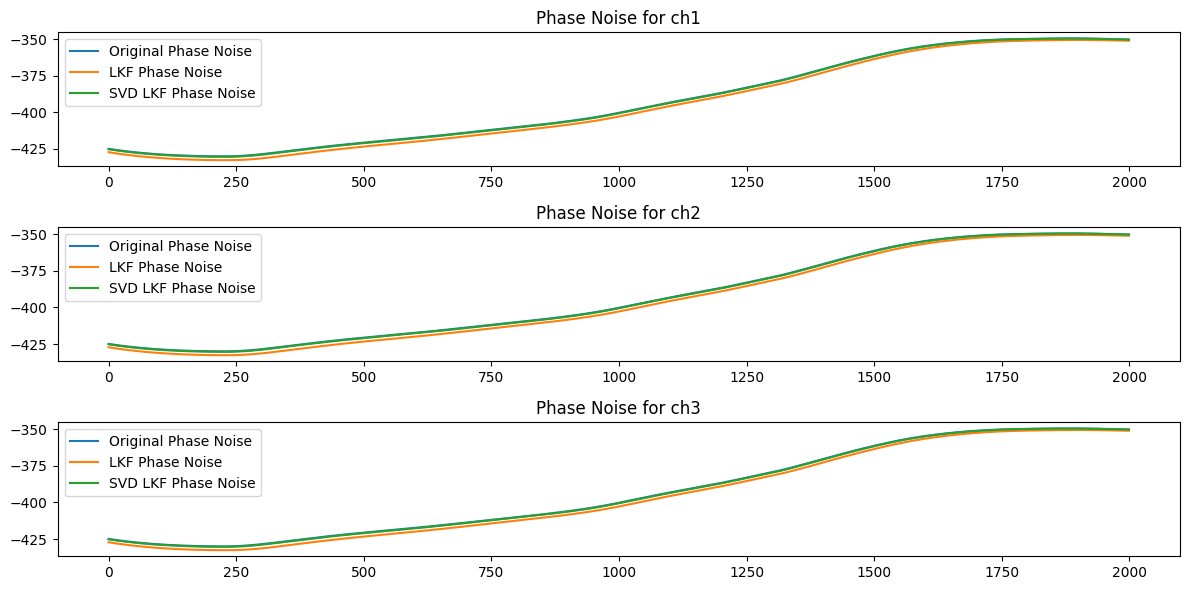

In [ ]:
import matplotlib.pyplot as plt

# Fit and remove linear trend from phase to visualize noise
def detrend_phase(signal):
    """Fit a line to the signal and return the residual (noise)"""
    x = np.arange(len(signal))
    coeffs = np.polyfit(x, signal, 1)  # Fit 1st degree polynomial (line)
    trend = np.polyval(coeffs, x)
    return signal - trend


point_range = [4000, 4500]

plt.figure(figsize=(12, 6))
for i, col in enumerate(columns_to_filter):
    plt.subplot(n_cols, 1, i + 1)
    
    # Detrend the original phase
    original_phase_noise = detrend_phase(df[col].values)
    plt.plot(original_phase_noise[point_range[0]:point_range[1]], label='Original Phase Noise')
    
    if use_lkf:
        lkf_phase_noise = detrend_phase(df[f"{col}_phase_lkf"].values)
        plt.plot(lkf_phase_noise[point_range[0]:point_range[1]], label='LKF Phase Noise')
    if use_svd_lkf:
        svd_phase_noise = detrend_phase(df[f"{col}_phase_svd_lkf"].values)
        plt.plot(svd_phase_noise[point_range[0]:point_range[1]], label='SVD LKF Phase Noise')

    plt.title(f"Phase Noise for {col}")
    plt.legend()
plt.tight_layout()
plt.show()